In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

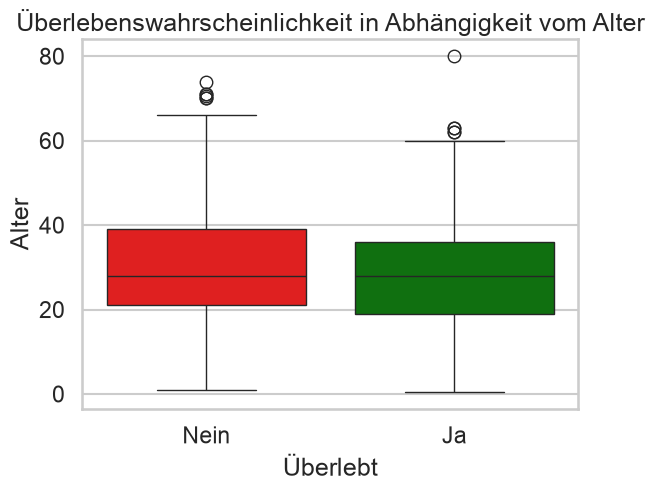

In [46]:
titanic_data = pd.read_parquet("../titanic.parquet")

colors = {0: "red", 1: "green"}

bp = sns.boxplot(x='Survived', y='Age', data=titanic_data, palette=colors, hue="Survived", legend=False)
#set(title="Überlebenswahrscheinlichkeit in Abhängigkeit vom Alter")
bp.set_title("Überlebenswahrscheinlichkeit in Abhängigkeit vom Alter")
bp.set_xlabel("Überlebt")
bp.set_ylabel("Alter")
bp.set_xticks([0, 1], ['Nein', 'Ja'])





Text(0.5, 1.0, 'Gestorbenenrate in Abhängigkeit vom Geschlecht')

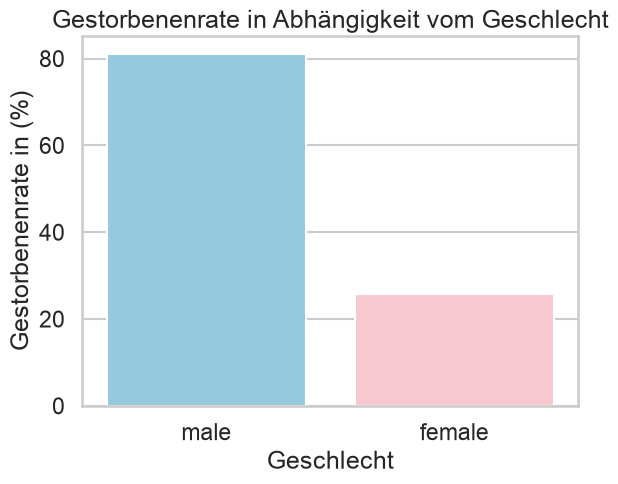

In [47]:
titanic_data = pd.read_parquet("../titanic.parquet")

filtered_data_male = titanic_data[titanic_data["Sex"] == "male"]
filtered_data_male_died = titanic_data[(titanic_data["Sex"] == "male") & (titanic_data["Survived"] == 0)]

filtered_data_female = titanic_data[titanic_data["Sex"] == "female"]
filtered_data_female_died = titanic_data[(titanic_data["Sex"] == "female") & (titanic_data["Survived"] == 0)]

gestorben_frauen = len(filtered_data_female_died) / len(filtered_data_female) * 100
gestorben_maenner = len(filtered_data_male_died) / len(filtered_data_male) * 100

plot_data = pd.DataFrame({
    "Geschlecht": ["male", "female"],
    "Gestorbenenrate in (%)": [gestorben_maenner, gestorben_frauen]
})

colors = ["skyblue", "pink"]
bp = sns.barplot(x="Geschlecht", y="Gestorbenenrate in (%)", data=plot_data, palette=colors, hue="Geschlecht")

bp.set_ylabel("Gestorbenenrate in (%)")
bp.set_xlabel("Geschlecht")
bp.set_title("Gestorbenenrate in Abhängigkeit vom Geschlecht")



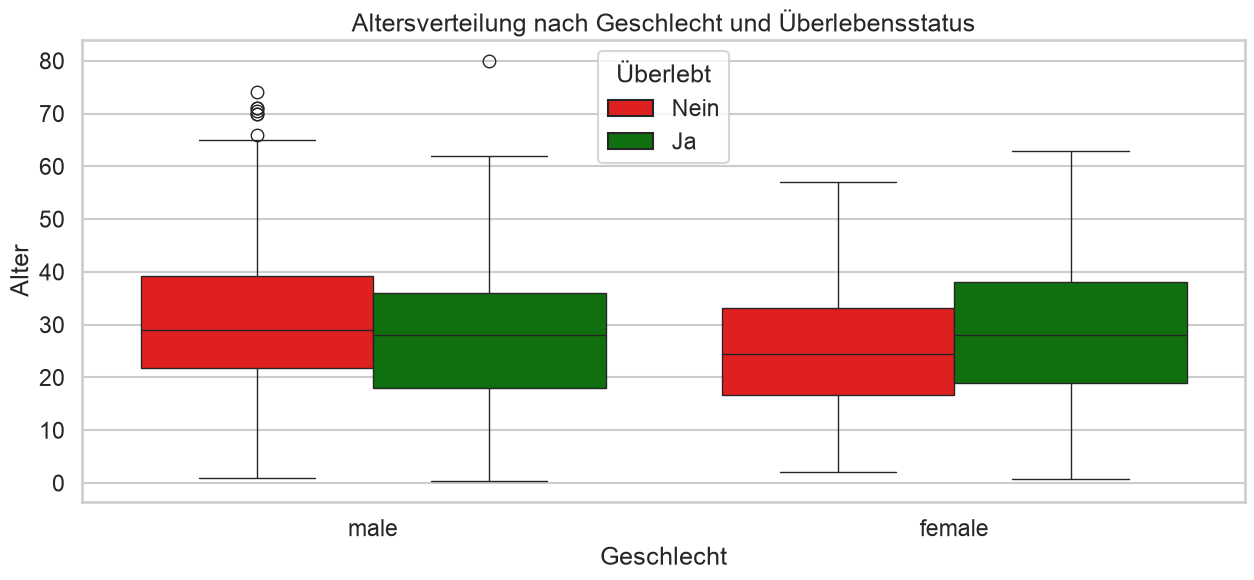

In [48]:
titanic_data = pd.read_parquet("../titanic.parquet")

colors = {0: "red", 1: "green"}

sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(15, 6))

bp = sns.boxplot(x="Sex", y="Age", hue="Survived", data=titanic_data, palette=colors, legend=True)
bp.set_title("Altersverteilung nach Geschlecht und Überlebensstatus")
bp.set_xlabel("Geschlecht")
bp.set_ylabel("Alter") 

handles, labels = bp.get_legend_handles_labels()
bp.legend(handles=handles, title="Überlebt", loc="upper center", labels=["Nein", "Ja"]) 

<Axes: xlabel='Group_Size'>

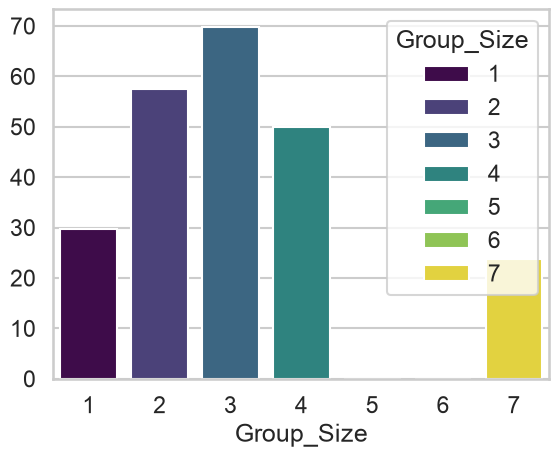

In [50]:
#hatten alleinreisende schlechtere überlebensschancen als zusammenreisende? (Ticketnummern vergleichen)

titanic_data = pd.read_parquet("../titanic.parquet")

titanic_data.head()

zusammenreisende = titanic_data["Ticket"].value_counts()

titanic_data["Group_Size"] = titanic_data["Ticket"].map(zusammenreisende)
ueberlebenschancen_dezimal = titanic_data.groupby("Group_Size")["Survived"].mean()

ueberlebenschancen_prozent = ueberlebenschancen_dezimal * 100

sns.set_theme(style="whitegrid", context="talk")

sns.barplot(x=ueberlebenschancen_prozent.index, y=ueberlebenschancen_prozent.values, palette="viridis", hue=ueberlebenschancen_prozent.index, legend=True)

